In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from xgboost import plot_importance
from warnings import filterwarnings

filterwarnings('ignore')
# plt.style.use('fivethirtyeight')
color_palette = sns.color_palette()

# Types of Time Series Data
![Time series](https://miro.medium.com/v2/resize:fit:1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg)

In [2]:
df = pd.read_csv('../data/PJME_hourly.csv',index_col=[0], parse_dates=[0])
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


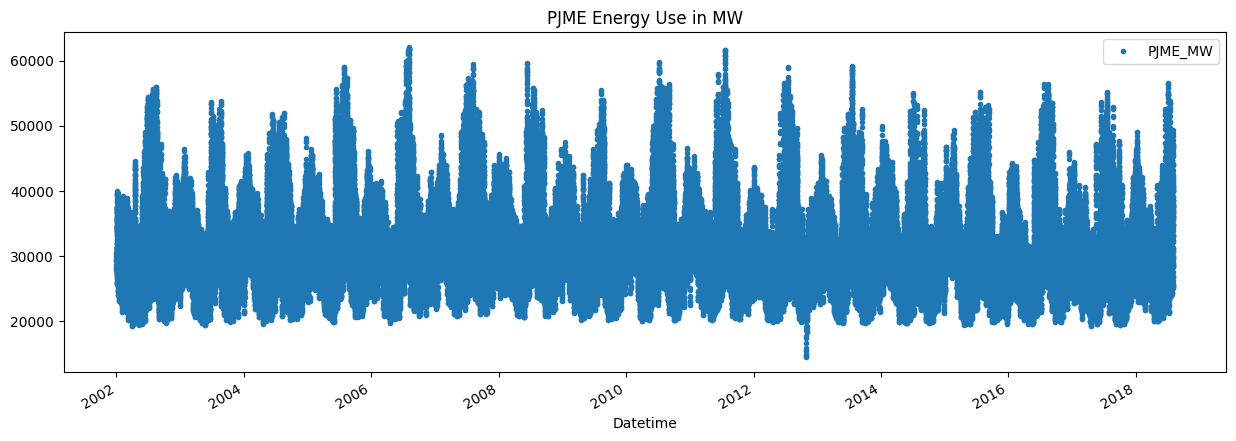

In [3]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_palette[0],
        title='PJME Energy Use in MW')
plt.show()

# Train / Test Split

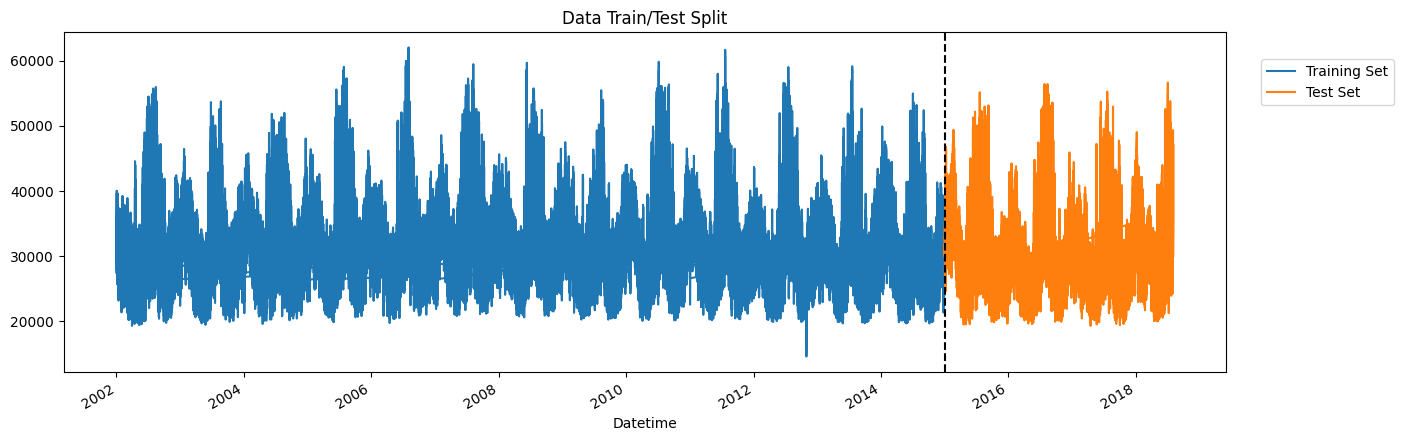

In [4]:
train_test_date = pd.to_datetime('01-01-2015')

train = df.loc[df.index < train_test_date]
test = df.loc[df.index >= train_test_date]

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline(train_test_date, color='black', ls='--')
ax.legend(['Training Set', 'Test Set'], loc = 'upper right', bbox_to_anchor=(1.15, 0.94))
plt.show()

<Axes: xlabel='Datetime'>

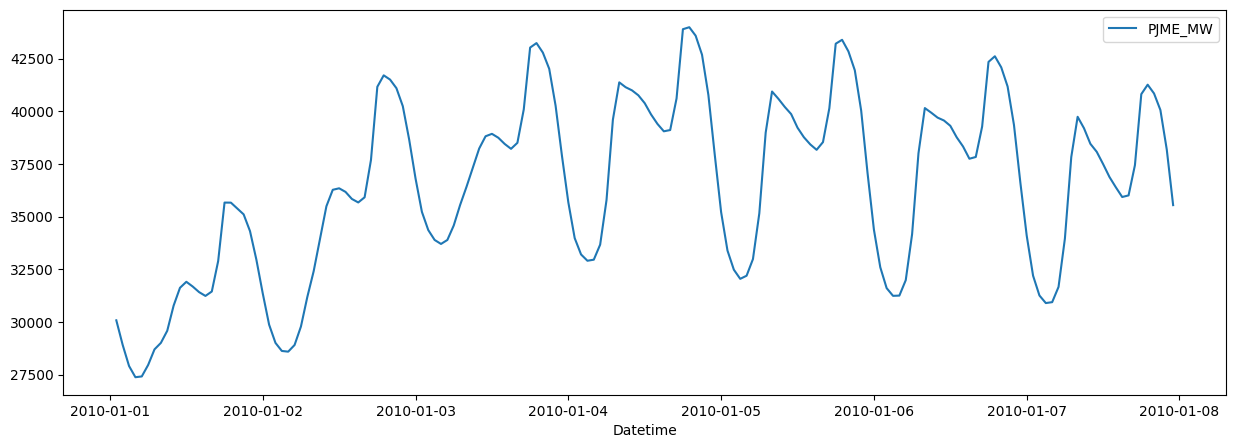

In [5]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data = df[(df.index > pd.to_datetime('01-01-2010')) & (df.index < pd.to_datetime('01-08-2010'))]
)

# Feature Creation

In [6]:
def create_features(df: pd.DataFrame):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,31,1
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,31,1
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,31,1
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,31,1
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,31,1
...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1


## Visualize our Feature / Target Relationship

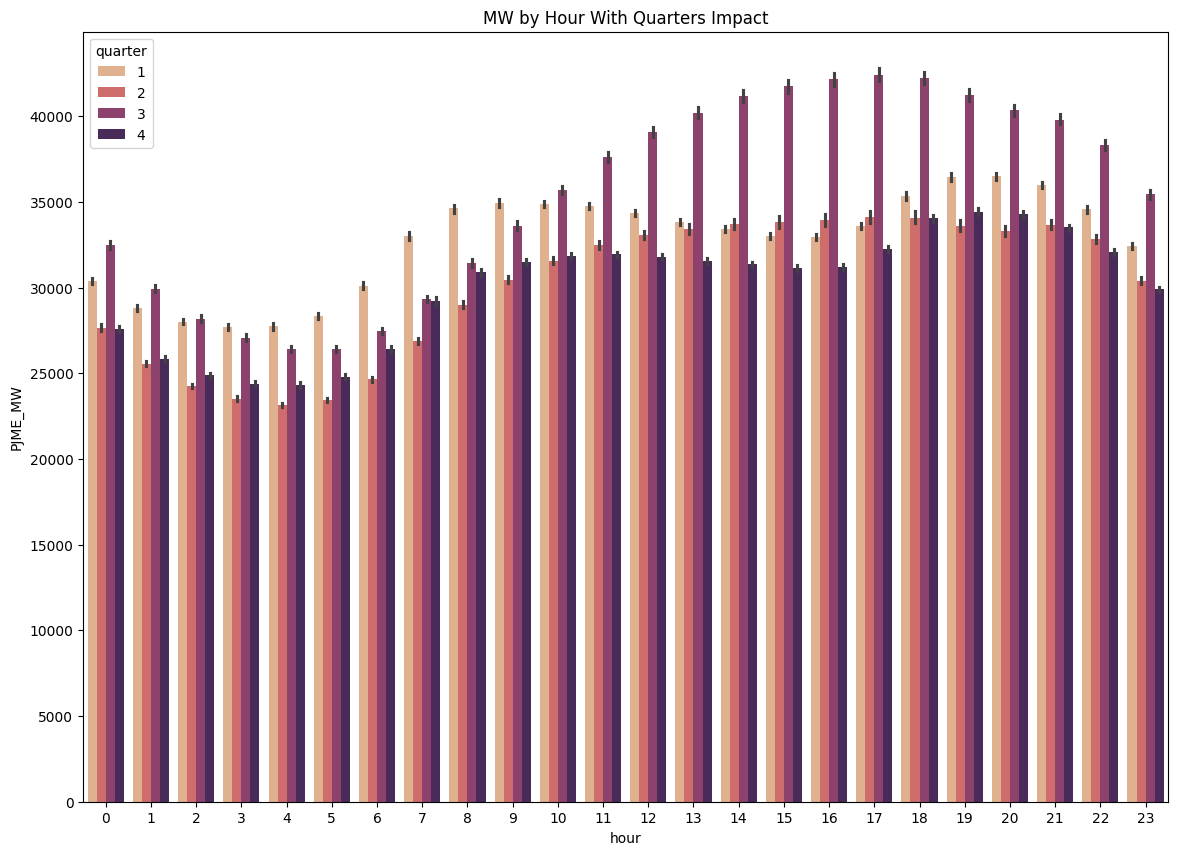

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))
sns.barplot(data=df, x='hour', y='PJME_MW', palette='flare', hue='quarter')
ax.set_title('MW by Hour With Quarters Impact')
plt.show()

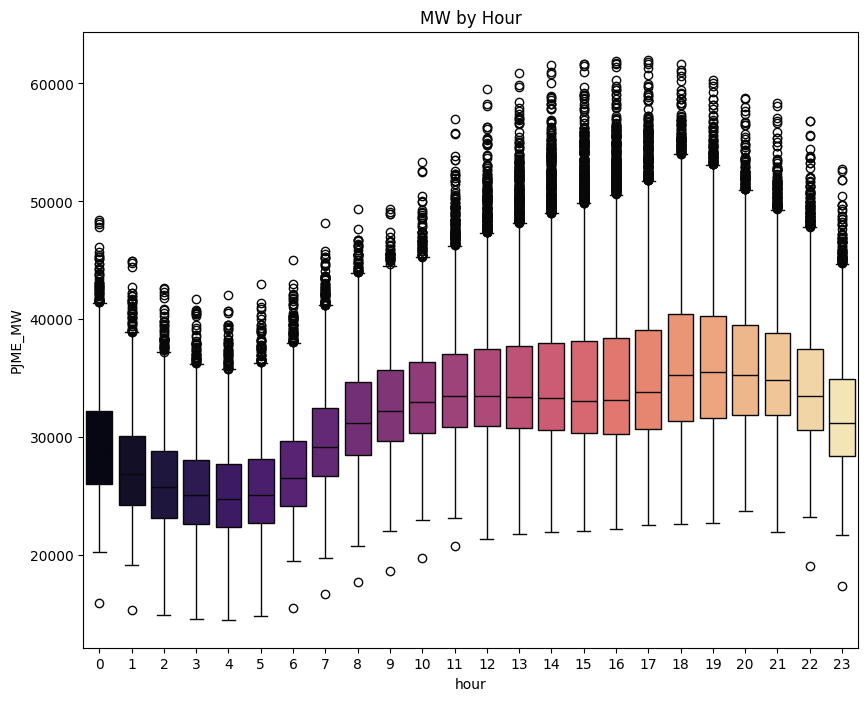

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW', palette='magma')
ax.set_title('MW by Hour')
plt.show()

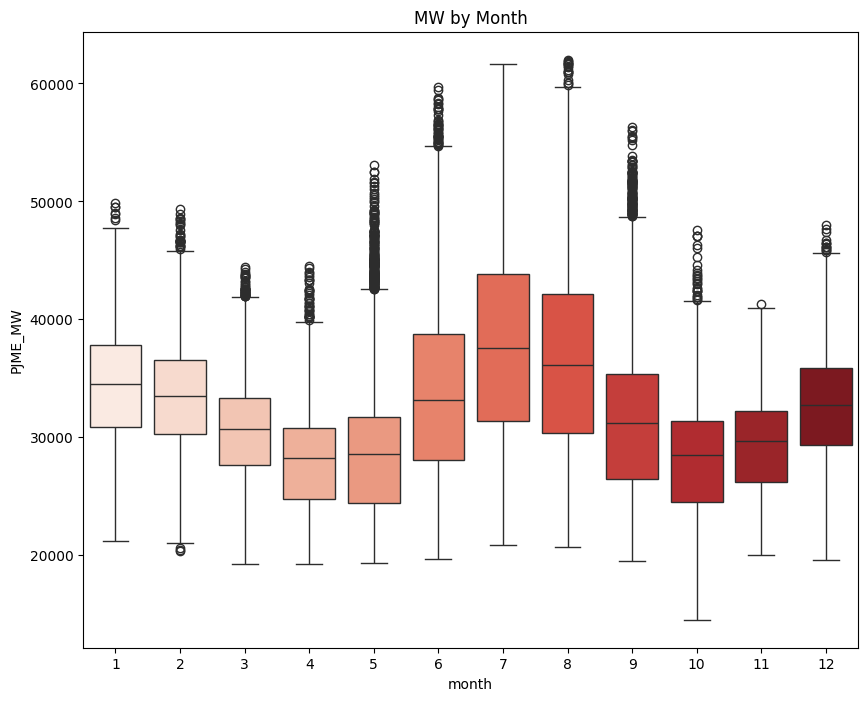

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='Reds')
ax.set_title('MW by Month')
plt.show()

# Training the model

In [10]:
training = create_features(train)
testing = create_features(test)

FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear']
TARGET = ['PJME_MW']

X_train, y_train = training[FEATURES], training[TARGET]
X_test, y_test = testing[FEATURES], testing[TARGET]

In [11]:
reg = xgb.XGBRegressor(
    base_score=0.5,
    booster='gbtree',
    n_estimators=1000,
    early_stopping_rounds=50,
    objective='reg:linear',
    max_depth=3,
    learning_rate=0.01
)
reg.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=110
)

[0]	validation_0-rmse:32605.13970	validation_1-rmse:31657.15729
[110]	validation_0-rmse:11513.64836	validation_1-rmse:10697.39709
[220]	validation_0-rmse:5227.56193	validation_1-rmse:4865.63020
[330]	validation_0-rmse:3713.09844	validation_1-rmse:3933.47224
[440]	validation_0-rmse:3368.52705	validation_1-rmse:3834.91355
[550]	validation_0-rmse:3240.31912	validation_1-rmse:3798.78305
[660]	validation_0-rmse:3168.18791	validation_1-rmse:3776.34294
[770]	validation_0-rmse:3119.42690	validation_1-rmse:3756.96020
[880]	validation_0-rmse:3083.05555	validation_1-rmse:3745.41039
[990]	validation_0-rmse:3050.97444	validation_1-rmse:3736.40136
[999]	validation_0-rmse:3048.28199	validation_1-rmse:3735.60177


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

## Feature importance

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

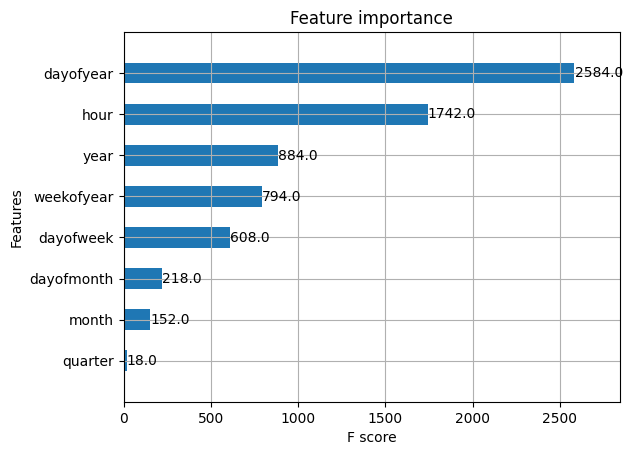

In [12]:
plot_importance(booster=reg, height=0.5)

In [13]:
testing['prediction'] = reg.predict(X_test)
df = df.merge(testing[['prediction']], how='left', left_index=True, right_index=True)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Datetime,,,,,,,,,,
2002-12-31 01:00:00,26498.0,1,1,4,12,2002,365,31,1,NaN
2002-12-31 02:00:00,25147.0,2,1,4,12,2002,365,31,1,NaN
2002-12-31 03:00:00,24574.0,3,1,4,12,2002,365,31,1,NaN
2002-12-31 04:00:00,24393.0,4,1,4,12,2002,365,31,1,NaN
2002-12-31 05:00:00,24860.0,5,1,4,12,2002,365,31,1,NaN
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1,36531.984375
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1,36476.074219
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1,35033.089844


In [14]:
testing

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction
Datetime,,,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,1,1,31402.861328
2015-12-31 01:00:00,24305.0,1,3,4,12,2015,365,31,53,28150.810547
2015-12-31 02:00:00,23156.0,2,3,4,12,2015,365,31,53,27144.492188
2015-12-31 03:00:00,22514.0,3,3,4,12,2015,365,31,53,26709.642578
2015-12-31 04:00:00,22330.0,4,3,4,12,2015,365,31,53,26709.642578
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1,36531.984375
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1,36476.074219
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1,35033.089844


# Forecast on Test

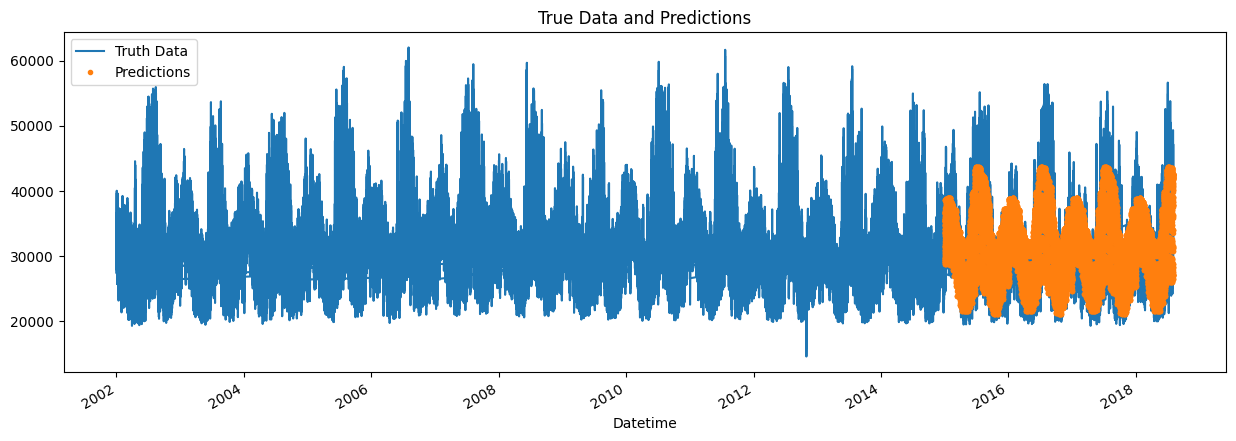

In [15]:
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('True Data and Predictions')
plt.show()

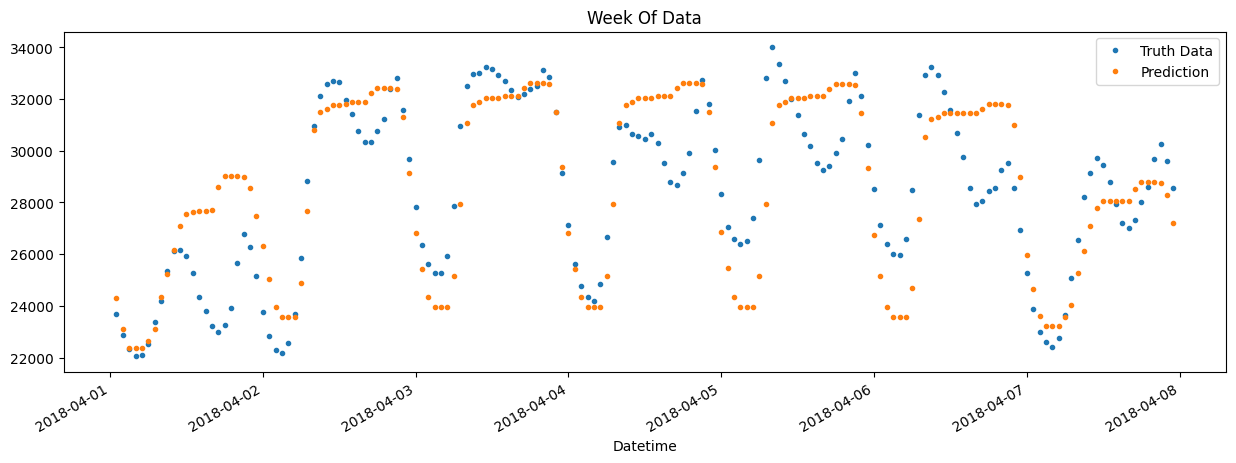

In [16]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data', style='.')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# Error metrics

In [17]:
score = np.sqrt(mean_squared_error(testing['PJME_MW'], testing['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 3735.60


In [18]:
testing['error'] = np.abs(testing['PJME_MW'] - testing['prediction'])
testing['date'] = testing.index.date
testing.groupby(['date', 'prediction'])['error'].mean().sort_values(ascending=False)

date        prediction  
2016-08-13  36542.250000    18356.750000
            37021.667969    18094.332031
            36489.347656    17429.652344
2016-08-14  35925.390625    17120.609375
2016-09-10  33328.496094    16924.503906
                                ...     
2015-05-16  26568.359375        1.640625
2017-02-16  34059.207031        0.792969
2016-08-30  37316.492188        0.507812
2015-07-12  37681.734375        0.265625
2018-05-16  31589.792969        0.207031
Name: error, Length: 25065, dtype: float64

In [19]:
testing

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction,error,date
Datetime,,,,,,,,,,,,
2015-01-01 00:00:00,32802.0,0,3,1,1,2015,1,1,1,31402.861328,1399.138672,2015-01-01
2015-12-31 01:00:00,24305.0,1,3,4,12,2015,365,31,53,28150.810547,3845.810547,2015-12-31
2015-12-31 02:00:00,23156.0,2,3,4,12,2015,365,31,53,27144.492188,3988.492188,2015-12-31
2015-12-31 03:00:00,22514.0,3,3,4,12,2015,365,31,53,26709.642578,4195.642578,2015-12-31
2015-12-31 04:00:00,22330.0,4,3,4,12,2015,365,31,53,26709.642578,4379.642578,2015-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,44284.0,20,0,1,1,2018,1,1,1,36531.984375,7752.015625,2018-01-01
2018-01-01 21:00:00,43751.0,21,0,1,1,2018,1,1,1,36476.074219,7274.925781,2018-01-01
2018-01-01 22:00:00,42402.0,22,0,1,1,2018,1,1,1,35033.089844,7368.910156,2018-01-01


# Look at Worst and Best Predicted Days

In [ ]:
testing.sort_values(by='error', ascending=True)[['dayofmonth', 'month', 'year', 'hour', 'PJME_MW', 'prediction', 'error']]

In [20]:
testing.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31440 entries, 2015-01-01 00:00:00 to 2018-01-02 00:00:00
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PJME_MW     31440 non-null  float64
 1   hour        31440 non-null  int32  
 2   dayofweek   31440 non-null  int32  
 3   quarter     31440 non-null  int32  
 4   month       31440 non-null  int32  
 5   year        31440 non-null  int32  
 6   dayofyear   31440 non-null  int32  
 7   dayofmonth  31440 non-null  int32  
 8   weekofyear  31440 non-null  UInt32 
 9   prediction  31440 non-null  float32
 10  error       31440 non-null  float64
 11  date        31440 non-null  object 
dtypes: UInt32(1), float32(1), float64(2), int32(7), object(1)
memory usage: 2.1+ MB


In [21]:
type_mapping = {
    'date': 'datetime64[ns]'
}

testing = testing.astype(type_mapping)
testing.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31440 entries, 2015-01-01 00:00:00 to 2018-01-02 00:00:00
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   PJME_MW     31440 non-null  float64       
 1   hour        31440 non-null  int32         
 2   dayofweek   31440 non-null  int32         
 3   quarter     31440 non-null  int32         
 4   month       31440 non-null  int32         
 5   year        31440 non-null  int32         
 6   dayofyear   31440 non-null  int32         
 7   dayofmonth  31440 non-null  int32         
 8   weekofyear  31440 non-null  UInt32        
 9   prediction  31440 non-null  float32       
 10  error       31440 non-null  float64       
 11  date        31440 non-null  datetime64[ns]
dtypes: UInt32(1), datetime64[ns](1), float32(1), float64(2), int32(7)
memory usage: 2.1 MB


In [22]:
forecasts_errors = testing.groupby(['date', 'hour', 'quarter'])\
    .mean()[['PJME_MW','prediction','error']]
forecasts_errors

PJME_MW    prediction        error
date       hour quarter                                    
2015-01-01 0    1        32802.0  31402.861328  1399.138672
           1    1        31647.0  30315.609375  1331.390625
           2    1        30755.0  29426.279297  1328.720703
           3    1        30189.0  29023.902344  1165.097656
           4    1        29890.0  29023.902344   866.097656
...                          ...           ...          ...
2018-08-02 20   3        44057.0  42518.074219  1538.925781
           21   3        43256.0  42329.328125   926.671875
           22   3        41552.0  40611.781250   940.218750
           23   3        38500.0  37744.406250   755.593750
2018-08-03 0    3        35486.0  31495.607422  3990.392578

[31437 rows x 3 columns]

In [23]:
forecasts_errors.index

MultiIndex([('2015-01-01',  0, 1),
            ('2015-01-01',  1, 1),
            ('2015-01-01',  2, 1),
            ('2015-01-01',  3, 1),
            ('2015-01-01',  4, 1),
            ('2015-01-01',  5, 1),
            ('2015-01-01',  6, 1),
            ('2015-01-01',  7, 1),
            ('2015-01-01',  8, 1),
            ('2015-01-01',  9, 1),
            ...
            ('2018-08-02', 15, 3),
            ('2018-08-02', 16, 3),
            ('2018-08-02', 17, 3),
            ('2018-08-02', 18, 3),
            ('2018-08-02', 19, 3),
            ('2018-08-02', 20, 3),
            ('2018-08-02', 21, 3),
            ('2018-08-02', 22, 3),
            ('2018-08-02', 23, 3),
            ('2018-08-03',  0, 3)],
           names=['date', 'hour', 'quarter'], length=31437)

In [24]:
forecasts_errors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 31437 entries, (Timestamp('2015-01-01 00:00:00'), 0, 1) to (Timestamp('2018-08-03 00:00:00'), 0, 3)
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PJME_MW     31437 non-null  float64
 1   prediction  31437 non-null  float32
 2   error       31437 non-null  float64
dtypes: float32(1), float64(2)
memory usage: 747.3 KB


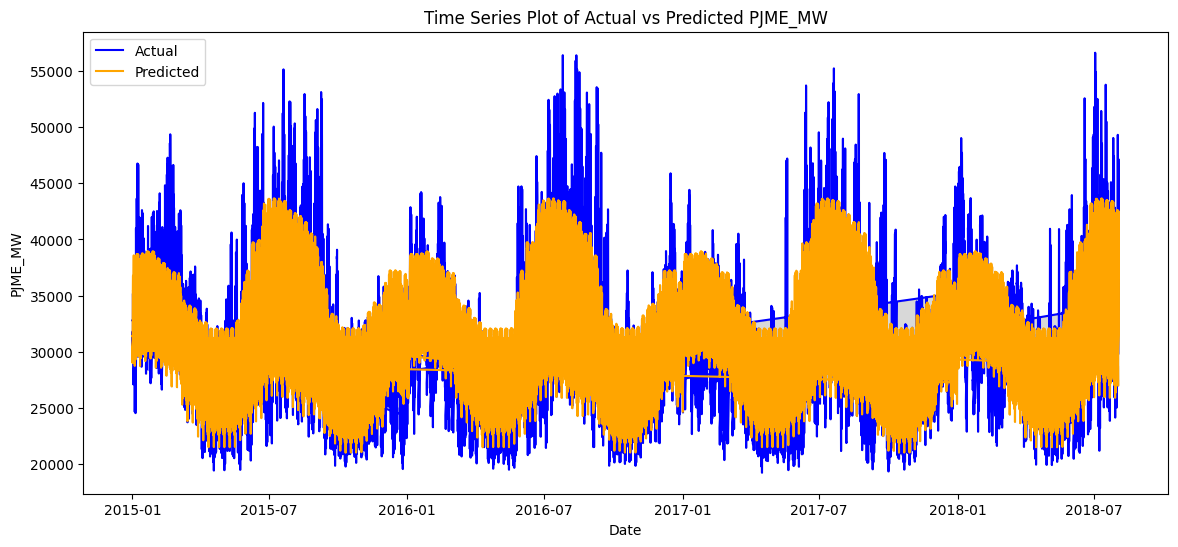

In [25]:
plt.figure(figsize=(14, 6))
plt.plot(testing.index, testing['PJME_MW'], label='Actual', color='blue')
plt.plot(testing.index, testing['prediction'], label='Predicted', color='orange')
plt.fill_between(testing.index, testing['PJME_MW'], testing['prediction'], color='gray', alpha=0.3)  # Shading the error

plt.xlabel("Date")
plt.ylabel("PJME_MW")
plt.title("Time Series Plot of Actual vs Predicted PJME_MW")
plt.legend()
plt.show()

# Hourly Time Series Forecasting using XGBoost

## Data acquiring

In [26]:
pjme = pd.read_csv('../data/PJME_hourly.csv', index_col=[0], parse_dates=[0])
pjme

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


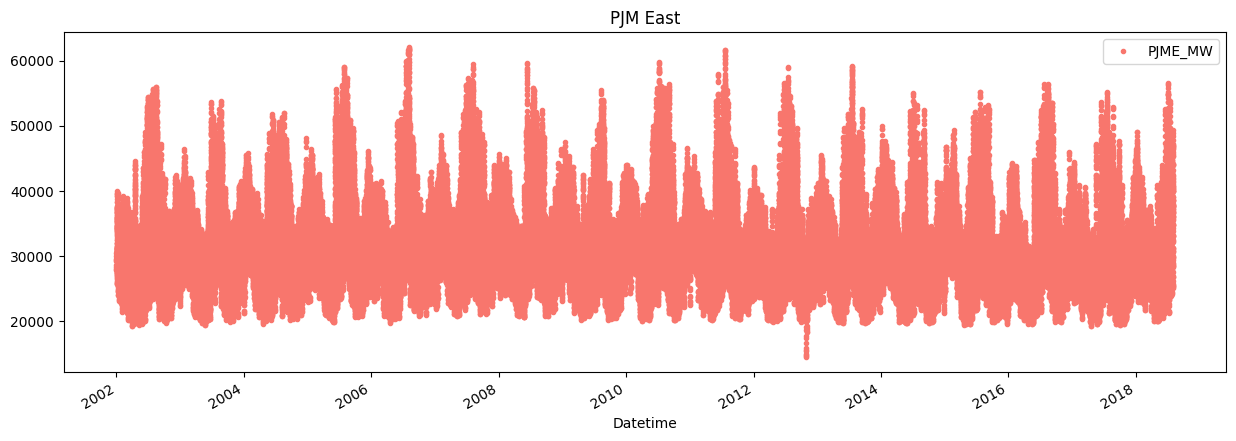

In [27]:
color_pal = ["#F8766D", "#D39200", "#93AA00", "#00BA38", "#00C19F", "#00B9E3", "#619CFF", "#DB72FB"]
_ = pjme.plot(style='.', figsize=(15,5), color=color_pal[0], title='PJM East')

In [28]:
year_list = list(set([ts.year for ts in pjme.index]))
year_list.sort()
year_list

[2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018]

In [29]:
pjme_split_date = pd.to_datetime('01-01-2013')
pjme_train = pjme.loc[pjme.index <= pjme_split_date].copy()
pjme_test = pjme.loc[pjme.index > pjme_split_date]

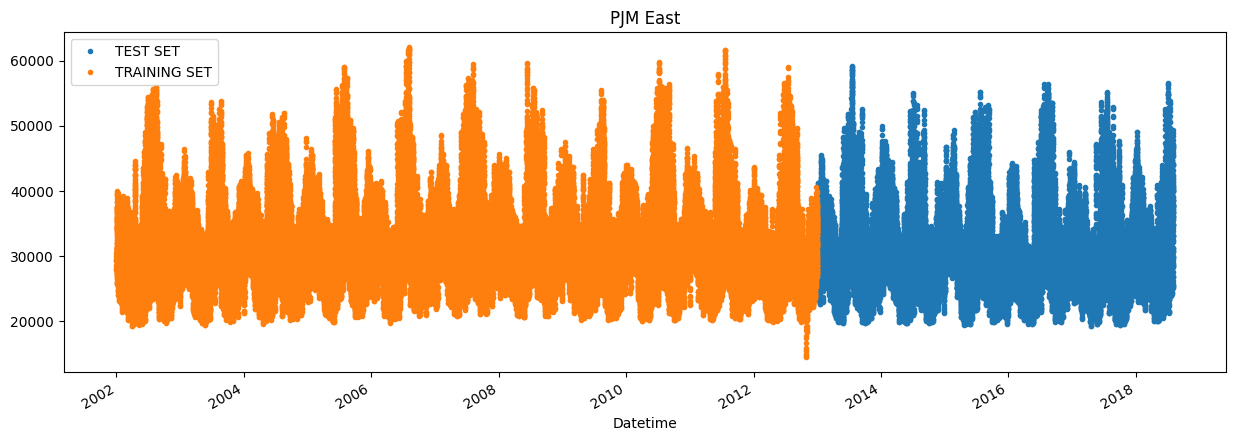

In [30]:
_ = pjme_test \
    .rename(columns={'PJME_MW': 'TEST SET'}) \
    .join(pjme_train.rename(columns={'PJME_MW': 'TRAINING SET'}), how='outer') \
    .plot(figsize=(15,5), title='PJM East', style='.')

# Feature Engineering

In [31]:
from pandas.api.types import CategoricalDtype

category_types = CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

def create_features(
    df: pd.DataFrame,
    label=None
) -> tuple[pd.DataFrame, pd.DataFrame] | pd.DataFrame:
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(category_types)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])
    X = df[['hour','dayofweek','quarter','month','year','dayofyear','dayofmonth','weekofyear','weekday','season']]
    if label:
        y = df[label]
        return X, y
    return X

X_pjme_train, y_pjme_train = create_features(pjme_train, label='PJME_MW')
X_pjme_test, y_pjme_test = create_features(pjme_test, label='PJME_MW')

In [32]:
X_pjme_test

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season
Datetime,,,,,,,,,,
2013-12-31 01:00:00,1,1,4,12,2013,365,31,1,Tuesday,Winter
2013-12-31 02:00:00,2,1,4,12,2013,365,31,1,Tuesday,Winter
2013-12-31 03:00:00,3,1,4,12,2013,365,31,1,Tuesday,Winter
2013-12-31 04:00:00,4,1,4,12,2013,365,31,1,Tuesday,Winter
2013-12-31 05:00:00,5,1,4,12,2013,365,31,1,Tuesday,Winter
...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter


In [33]:
y_pjme_test

Datetime
2013-12-31 01:00:00    30254.0
2013-12-31 02:00:00    29241.0
2013-12-31 03:00:00    28772.0
2013-12-31 04:00:00    28762.0
2013-12-31 05:00:00    29391.0
                        ...   
2018-01-01 20:00:00    44284.0
2018-01-01 21:00:00    43751.0
2018-01-01 22:00:00    42402.0
2018-01-01 23:00:00    40164.0
2018-01-02 00:00:00    38608.0
Name: PJME_MW, Length: 48957, dtype: float64

# Create XGBoostRegressor Model

In [34]:
xg_reg = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    booster='gbtree',
    objective='reg:linear',
    max_depth=3,
    enable_categorical=True,
    learning_rate=0.01
)
xg_reg.fit(
    X_pjme_train, y_pjme_train,
    eval_set=[(X_pjme_train, y_pjme_train), (X_pjme_test, y_pjme_test)],
    verbose=True
)

[0]	validation_0-rmse:6454.53180	validation_1-rmse:6403.32312
[1]	validation_0-rmse:6418.57762	validation_1-rmse:6370.45144
[2]	validation_0-rmse:6383.12000	validation_1-rmse:6338.41591
[3]	validation_0-rmse:6348.16094	validation_1-rmse:6306.54011
[4]	validation_0-rmse:6313.68279	validation_1-rmse:6275.57053
[5]	validation_0-rmse:6279.69038	validation_1-rmse:6244.66173
[6]	validation_0-rmse:6246.16080	validation_1-rmse:6214.56579
[7]	validation_0-rmse:6213.11449	validation_1-rmse:6184.60233
[8]	validation_0-rmse:6180.51954	validation_1-rmse:6155.52509
[9]	validation_0-rmse:6148.39556	validation_1-rmse:6126.86519
[10]	validation_0-rmse:6116.70836	validation_1-rmse:6098.26156
[11]	validation_0-rmse:6085.48670	validation_1-rmse:6070.55774
[12]	validation_0-rmse:6054.69379	validation_1-rmse:6042.84496
[13]	validation_0-rmse:6024.34781	validation_1-rmse:6015.96518
[14]	validation_0-rmse:5994.42783	validation_1-rmse:5989.12114
[15]	validation_0-rmse:5964.94432	validation_1-rmse:5963.15114
[1

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

## Feature Importance
Feature importance is a great way to get a general idea about which features the model is relying on most to make the prediction. This is a metric that simply sums up how many times each feature is split on.

We can see that the day of year was most commonly used to split trees, while hour and year came in next. Quarter has low importance due to the fact that it could be created by different dayofyear splits.

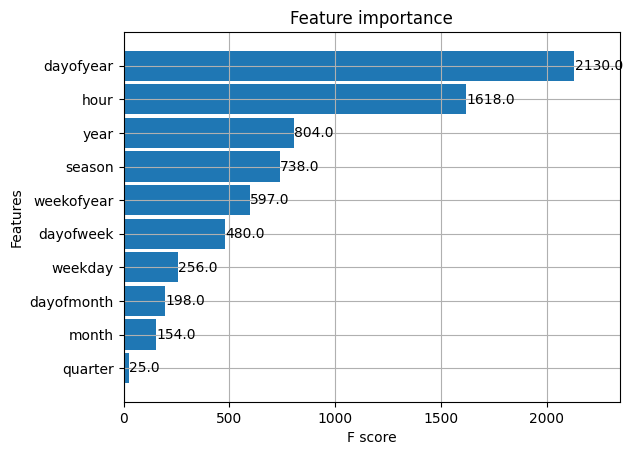

In [35]:
_ = plot_importance(xg_reg, height=0.9)

## Model predictions

In [36]:
pjme_test

,PJME_MW
Datetime,
2013-12-31 01:00:00,30254.0
2013-12-31 02:00:00,29241.0
2013-12-31 03:00:00,28772.0
2013-12-31 04:00:00,28762.0
2013-12-31 05:00:00,29391.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [37]:
pjme_test['MW_Prediction'] = xg_reg.predict(X_pjme_test)
pjme_all = pd.concat([pjme_train, pjme_test], sort=False)
pjme_all

,PJME_MW,MW_Prediction
Datetime,,
2002-12-31 01:00:00,26498.0,NaN
2002-12-31 02:00:00,25147.0,NaN
2002-12-31 03:00:00,24574.0,NaN
2002-12-31 04:00:00,24393.0,NaN
2002-12-31 05:00:00,24860.0,NaN
...,...,...
2018-01-01 20:00:00,44284.0,35592.320312
2018-01-01 21:00:00,43751.0,35542.417969
2018-01-01 22:00:00,42402.0,34210.031250


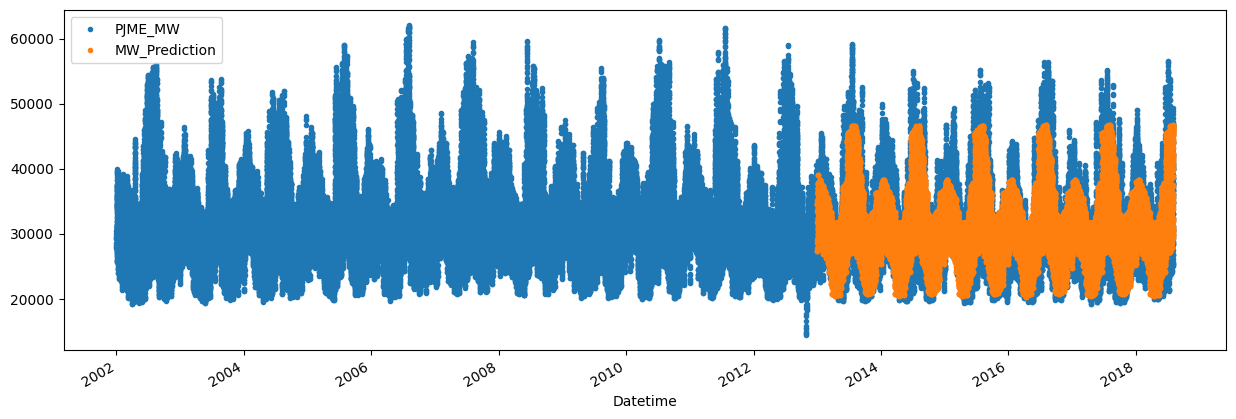

In [38]:
_ = pjme_all[['PJME_MW','MW_Prediction']].plot(figsize=(15, 5), style=['.', '.'])

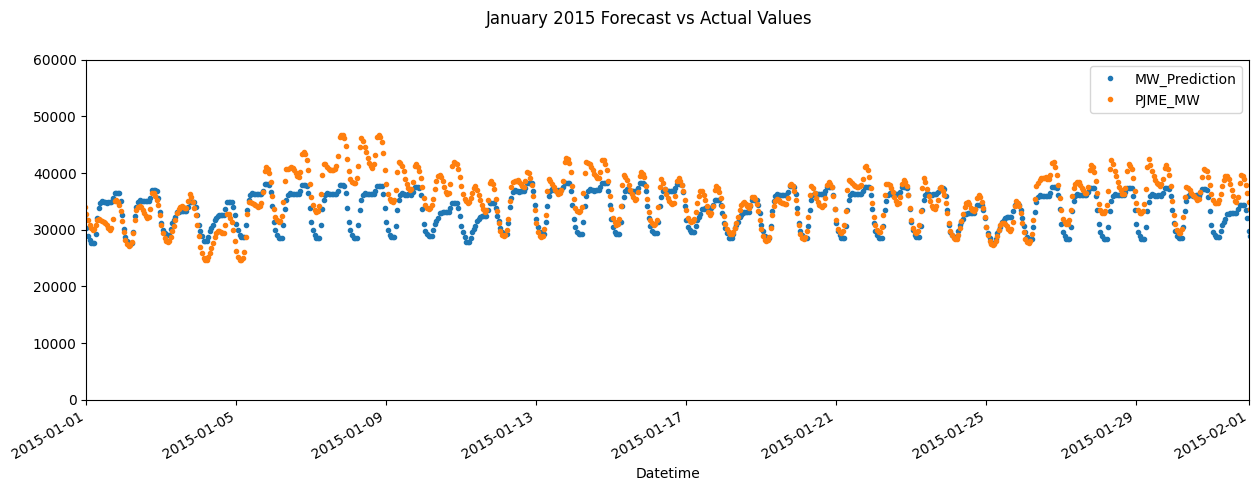

In [39]:
# Plot the forecast with the actual values
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = pjme_all[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_xbound(lower='01-01-2015', upper='02-01-2015')
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actual Values')

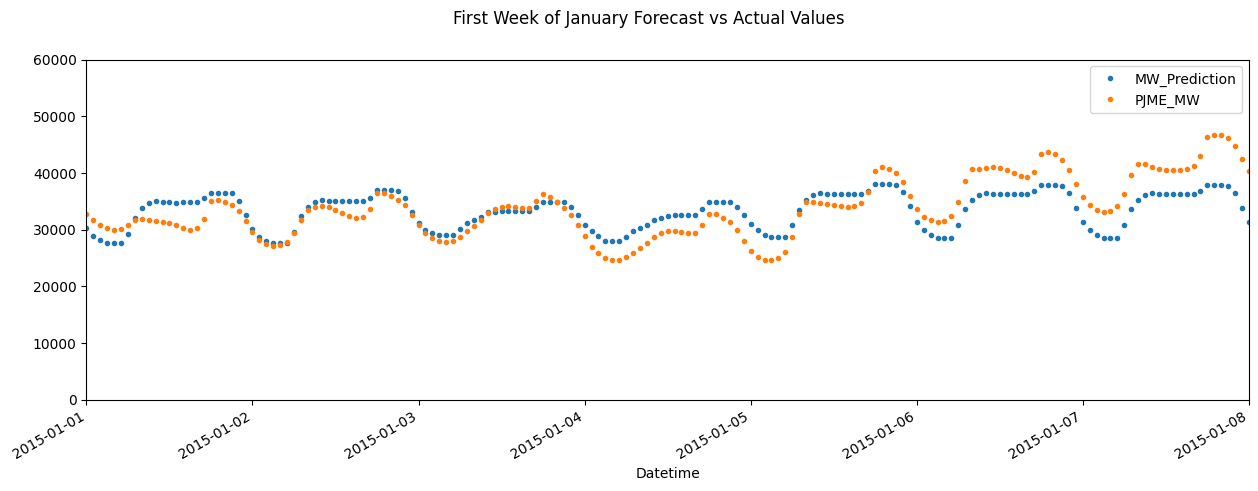

In [40]:
# Plot the forecast with the actual values
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = pjme_all[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_xbound(lower='01-01-2015', upper='01-08-2015')
ax.set_ylim(0, 60000)
plot = plt.suptitle('First Week of January Forecast vs Actual Values')

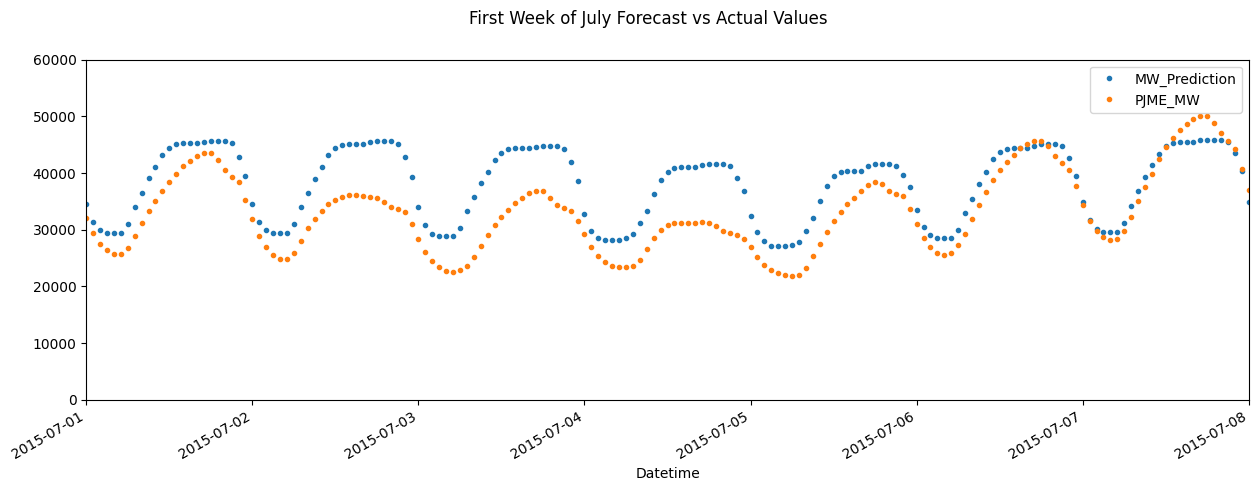

In [41]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(15)
_ = pjme_all[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_ylim(0, 60000)
ax.set_xbound(lower='07-01-2015', upper='07-08-2015')
plot = plt.suptitle('First Week of July Forecast vs Actual Values')

# Error Metrics On Test Set

In [43]:
mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test['MW_Prediction'])

14204860.457941039

In [44]:
from numpy import sqrt
sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test['MW_Prediction']))

3768.9335969131957

In [45]:
mean_absolute_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test['MW_Prediction'])

2891.8100587234076

In [46]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'], y_pred=pjme_test['MW_Prediction'])

0.09080139299151332

# Worst and Best Predicted Days

In [47]:
pjme_test

,PJME_MW,MW_Prediction
Datetime,,
2013-12-31 01:00:00,30254.0,27643.695312
2013-12-31 02:00:00,29241.0,26866.060547
2013-12-31 03:00:00,28772.0,26388.761719
2013-12-31 04:00:00,28762.0,26388.761719
2013-12-31 05:00:00,29391.0,26388.761719
...,...,...
2018-01-01 20:00:00,44284.0,35592.320312
2018-01-01 21:00:00,43751.0,35542.417969
2018-01-01 22:00:00,42402.0,34210.031250


In [48]:
from pandas.api.types import CategoricalDtype

category_types = CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

def create_features(
    df: pd.DataFrame,
    label=None
) -> tuple[pd.DataFrame, pd.DataFrame] | pd.DataFrame:
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(category_types)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], labels=['Spring', 'Summer', 'Fall', 'Winter'])
    X = df[['hour','dayofweek','quarter','month','year','dayofyear','dayofmonth','weekofyear','weekday','season']]
    if label:
        y = df[label]
        return X, y
    return X

full_pjme = create_features(pjme)
full_pjme['PJME_MW'] = pjme['PJME_MW']
full_pjme

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW
Datetime,,,,,,,,,,,
2002-12-31 01:00:00,1,1,4,12,2002,365,31,1,Tuesday,Winter,26498.0
2002-12-31 02:00:00,2,1,4,12,2002,365,31,1,Tuesday,Winter,25147.0
2002-12-31 03:00:00,3,1,4,12,2002,365,31,1,Tuesday,Winter,24574.0
2002-12-31 04:00:00,4,1,4,12,2002,365,31,1,Tuesday,Winter,24393.0
2002-12-31 05:00:00,5,1,4,12,2002,365,31,1,Tuesday,Winter,24860.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


In [49]:
full_pjme_test = full_pjme[full_pjme.index > pjme_split_date]
full_pjme_test

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW
Datetime,,,,,,,,,,,
2013-12-31 01:00:00,1,1,4,12,2013,365,31,1,Tuesday,Winter,30254.0
2013-12-31 02:00:00,2,1,4,12,2013,365,31,1,Tuesday,Winter,29241.0
2013-12-31 03:00:00,3,1,4,12,2013,365,31,1,Tuesday,Winter,28772.0
2013-12-31 04:00:00,4,1,4,12,2013,365,31,1,Tuesday,Winter,28762.0
2013-12-31 05:00:00,5,1,4,12,2013,365,31,1,Tuesday,Winter,29391.0
...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0


In [50]:
full_pjme_test['MW_Prediction'] = pjme_test['MW_Prediction']

In [51]:
full_pjme_test

,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,weekday,season,PJME_MW,MW_Prediction
Datetime,,,,,,,,,,,,
2013-12-31 01:00:00,1,1,4,12,2013,365,31,1,Tuesday,Winter,30254.0,27643.695312
2013-12-31 02:00:00,2,1,4,12,2013,365,31,1,Tuesday,Winter,29241.0,26866.060547
2013-12-31 03:00:00,3,1,4,12,2013,365,31,1,Tuesday,Winter,28772.0,26388.761719
2013-12-31 04:00:00,4,1,4,12,2013,365,31,1,Tuesday,Winter,28762.0,26388.761719
2013-12-31 05:00:00,5,1,4,12,2013,365,31,1,Tuesday,Winter,29391.0,26388.761719
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-01-01 20:00:00,20,0,1,1,2018,1,1,1,Monday,Winter,44284.0,35592.320312
2018-01-01 21:00:00,21,0,1,1,2018,1,1,1,Monday,Winter,43751.0,35542.417969
2018-01-01 22:00:00,22,0,1,1,2018,1,1,1,Monday,Winter,42402.0,34210.031250


In [52]:
full_pjme_test['error'] = full_pjme_test['PJME_MW'] - full_pjme_test['MW_Prediction']
full_pjme_test['abs_error'] = full_pjme_test['error'].apply(np.abs)
full_test_df = full_pjme_test.select_dtypes(include=np.number)
error_by_day = full_test_df.groupby(['year','month','dayofmonth']) \
    .mean()[['PJME_MW','MW_Prediction','error','abs_error']]
error_by_day

PJME_MW  MW_Prediction        error    abs_error
year month dayofmonth                                                       
2013 1     1           30466.217391   32904.652344 -2438.435547  2438.435547
           2           34623.708333   35231.121094  -607.415202  1347.759603
           3           35849.333333   34459.187500  1390.145264  1680.984456
           4           34857.875000   34384.570312   473.304362  1050.750977
           5           31770.416667   32289.828125  -519.412191   875.972575
...                             ...            ...          ...          ...
2018 7     30          32957.416667   39373.609375 -6416.191976  6416.191976
           31          34539.083333   40210.574219 -5671.490479  5671.490479
     8     1           39230.791667   40447.394531 -1216.600667  1943.036540
           2           39593.041667   40403.234375  -810.192790  1425.880778
           3           35486.000000   34993.945312   492.054688   492.054688

[2041 rows x 4 columns]

The best predicted days seem to be a lot of october (not many holidays and mild weather) Also early may

In [53]:
# Best predicted days
error_by_day.sort_values('abs_error', ascending=True).head(10)

PJME_MW  MW_Prediction       error   abs_error
year month dayofmonth                                                     
2014 4     15          28217.500000   28419.306641 -201.806478  330.499512
2013 10    17          28519.083333   28663.945312 -144.861816  337.277669
2014 10    1           28823.291667   28930.482422 -107.190999  355.363525
2017 9     18          31864.958333   31696.744141  168.214274  367.887939
2013 4     19          27990.916667   28233.087891 -242.173096  369.564535
           12          28245.166667   28082.052734  163.114014  445.598389
2014 4     14          27603.166667   28048.578125 -445.411621  462.678874
2017 10    15          25363.250000   25444.263672  -81.011882  478.095215
2013 3     1           32230.750000   32085.263672  145.488037  483.346924
2018 8     3           35486.000000   34993.945312  492.054688  492.054688

# Plotting some best/worst predicted days

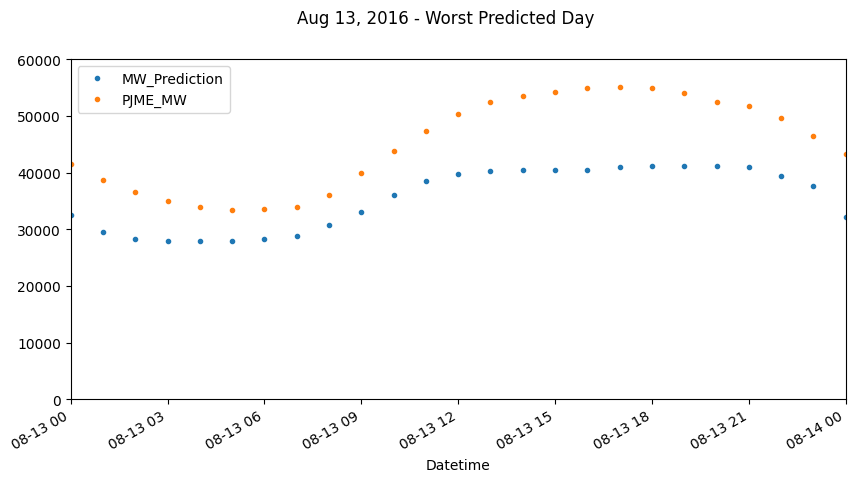

In [54]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(10)
_ = full_pjme_test[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_ylim(0, 60000)
ax.set_xbound(lower='08-13-2016', upper='08-14-2016')
plot = plt.suptitle('Aug 13, 2016 - Worst Predicted Day')

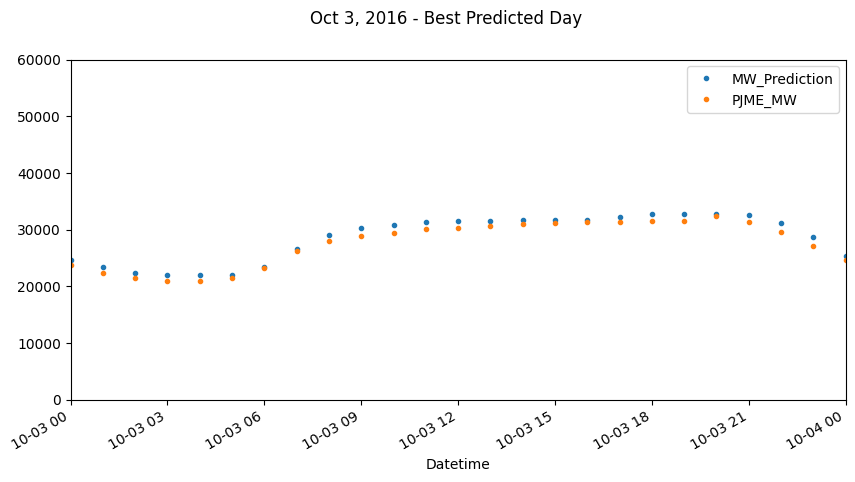

In [55]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(10)
_ = full_pjme_test[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_ylim(0, 60000)
ax.set_xbound(lower='10-03-2016', upper='10-04-2016')
plot = plt.suptitle('Oct 3, 2016 - Best Predicted Day')

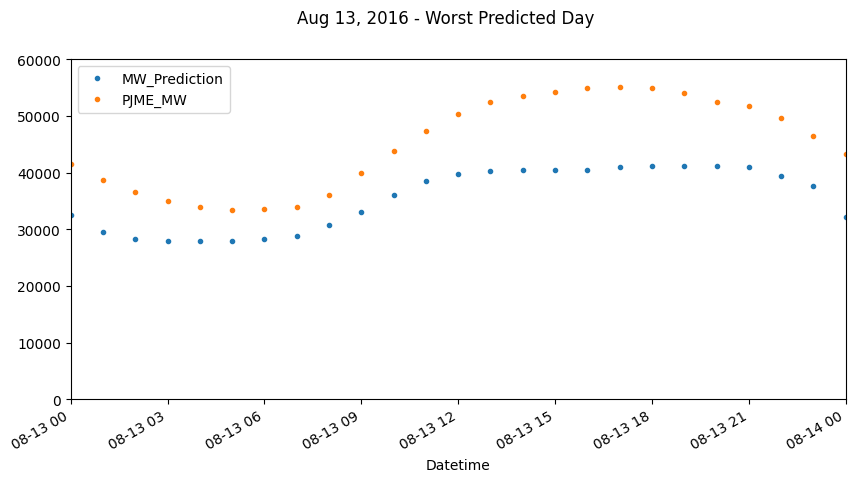

In [56]:
f, ax = plt.subplots(1)
f.set_figheight(5)
f.set_figwidth(10)
_ = full_pjme_test[['MW_Prediction','PJME_MW']].plot(ax=ax, style=['.','.'])
ax.set_ylim(0, 60000)
ax.set_xbound(lower='08-13-2016', upper='08-14-2016')
plot = plt.suptitle('Aug 13, 2016 - Worst Predicted Day')

# Parameter tuned XGBoost model

## Train/Test matrix

In [59]:
import xgboost as xgb

matrix_train = xgb.DMatrix(X_pjme_train, label=y_pjme_train, enable_categorical=True)
matrix_test = xgb.DMatrix(X_pjme_test, label=y_pjme_test, enable_categorical=True)

## Optimal parameterized model

In [121]:
params = {
    'n_estimators': 1500,
    'early_stopping_rounds':50,
    'booster':'gbtree',
    'enable_categorical':True,
    'objective':'reg:linear',
    'max_depth':15,
    'learning_rate': 0.1,
    'subsample': 0.5,
}

epoch = 10

param_tuned_model = xgb.train(params, matrix_train, epoch)

## Predict

In [122]:
prediction_tuned = param_tuned_model.predict(data=matrix_test)
prediction_tuned

array([30952.793, 30483.574, 30069.863, ..., 34102.785, 32960.504,
       31377.654], dtype=float32)

## Error metrics of tuned model

In [123]:
mean_squared_error(y_true=pjme_test['PJME_MW'], y_pred=prediction_tuned)

16972668.06221387

# Suggestions
* Add Lag variables.
* Add holidays.
* Add weather data source.